In [1]:
#imported libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#dataset loading 
df = pd.read_csv("../data/gold_historical_data.csv")
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2016-02-05,1157.800049,1157.800049,1174.800049,1146.000000,1155.599976,877
1,2016-02-08,1197.900024,1197.900024,1200.400024,1165.000000,1173.500000,931
2,2016-02-09,1198.699951,1198.699951,1199.199951,1186.699951,1188.699951,700
3,2016-02-10,1194.699951,1194.699951,1197.699951,1182.099976,1189.800049,671
4,2016-02-11,1247.900024,1247.900024,1260.800049,1204.599976,1205.599976,995


In [9]:
#info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2510 non-null   object 
 1   Adj Close  2510 non-null   float64
 2   Close      2510 non-null   float64
 3   High       2510 non-null   float64
 4   Low        2510 non-null   float64
 5   Open       2510 non-null   float64
 6   Volume     2510 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 137.4+ KB


In [10]:
#stats
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,2510.000000,2510.000000,2510.000000,2510.000000,2510.000000,2510.000000
mean,1862.680556,1862.680556,1872.036176,1852.944064,1862.260478,5161.460558
std,713.045002,713.045002,719.366255,706.561716,712.946710,28443.386437
min,1127.800049,1127.800049,1132.800049,1123.900024,1126.900024,0.000000
25%,1306.224976,1306.224976,1310.325043,1301.624969,1306.224976,53.250000
50%,1767.350037,1767.350037,1777.200012,1759.900024,1768.049988,213.000000
75%,1968.975006,1968.975006,1978.375031,1960.599976,1969.325012,655.500000
max,5318.399902,5318.399902,5586.200195,5301.600098,5415.700195,386334.000000


In [12]:
#missing value check
df.isnull().sum()

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [25]:
#date column coversion
df['Date'] = pd.to_datetime(df['Date'])

,Date,Adj Close,Close,High,Low,Open,Volume,Year
0,2016-02-05,1157.800049,1157.800049,1174.800049,1146.000000,1155.599976,877,2016
1,2016-02-08,1197.900024,1197.900024,1200.400024,1165.000000,1173.500000,931,2016
2,2016-02-09,1198.699951,1198.699951,1199.199951,1186.699951,1188.699951,700,2016
3,2016-02-10,1194.699951,1194.699951,1197.699951,1182.099976,1189.800049,671,2016
4,2016-02-11,1247.900024,1247.900024,1260.800049,1204.599976,1205.599976,995,2016
...,...,...,...,...,...,...,...,...
2505,2026-01-26,5079.700195,5079.700195,5095.600098,5052.200195,5081.500000,180,2026
2506,2026-01-27,5079.899902,5079.899902,5079.899902,5079.899902,5079.899902,34,2026
2507,2026-01-28,5301.600098,5301.600098,5301.600098,5301.600098,5301.600098,112054,2026
2508,2026-01-29,5318.399902,5318.399902,5586.200195,5097.500000,5415.700195,23709,2026


In [24]:
#added year feature to see in which year price was up
df['Year'] = df['Date'].dt.year
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Year
0,2016-02-05,1157.800049,1157.800049,1174.800049,1146.000000,1155.599976,877,2016
1,2016-02-08,1197.900024,1197.900024,1200.400024,1165.000000,1173.500000,931,2016
2,2016-02-09,1198.699951,1198.699951,1199.199951,1186.699951,1188.699951,700,2016
3,2016-02-10,1194.699951,1194.699951,1197.699951,1182.099976,1189.800049,671,2016
4,2016-02-11,1247.900024,1247.900024,1260.800049,1204.599976,1205.599976,995,2016


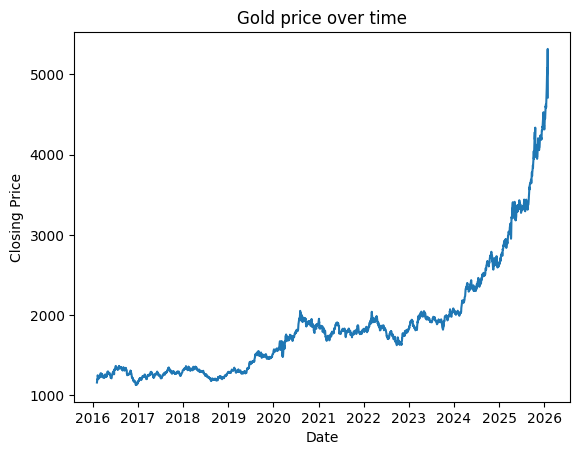

In [42]:
#gold price over time - Visualization 1

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.Figure(figsize=(15,10))
plt.title("Gold price over time")
plt.plot(df['Date'], df['Close'])
plt.show()


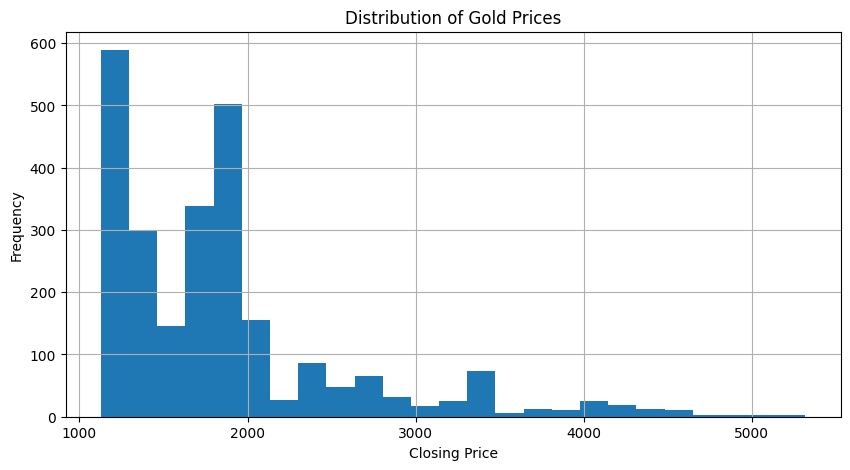

In [ ]:
#price distribution - histogram - 2
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.figure(figsize=(10,5))
plt.title("Distribution of gold prices")
df['Close'].hist(bins=25)
plt.show()

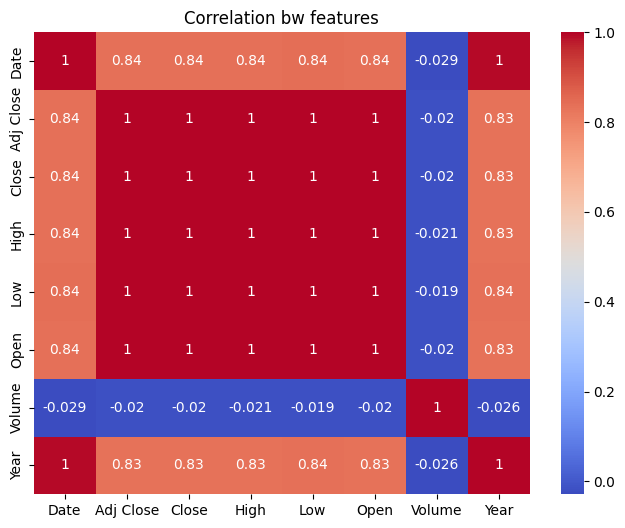

In [45]:
#correlation heatmap - 3
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation bw features")
plt.show()

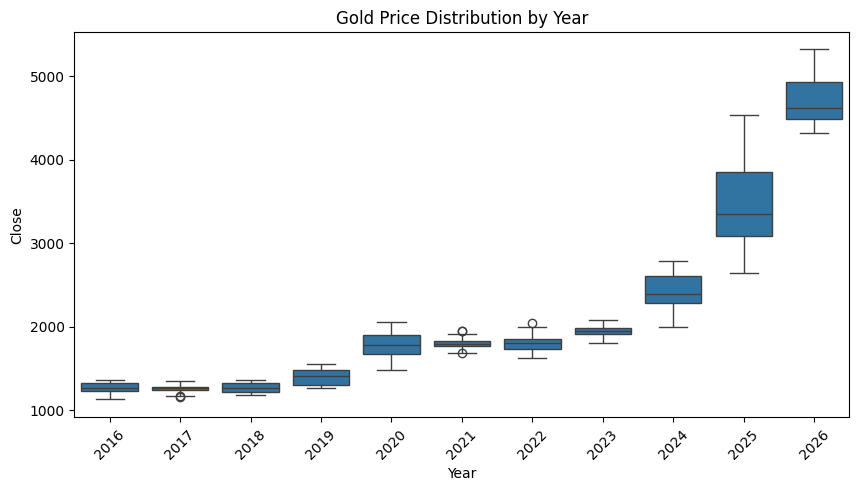

In [ ]:
#closing price per year - boxplot- 4

plt.figure(figsize=(10,5))
plt.title("Gold Price Distribution by Year")
sns.boxplot(x='Year', y='Close', data=df)
plt.xticks(rotation=45)
plt.show()


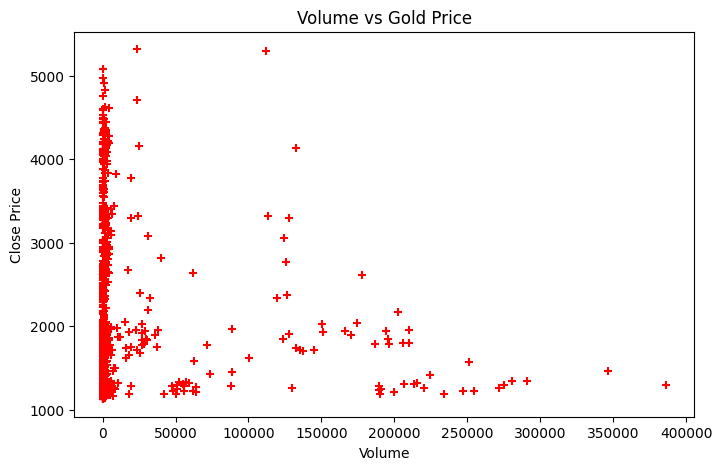

In [ ]:
#to see relationship bw trading volume and closing price - scatter plot -5
plt.figure(figsize=(8,5))
plt.scatter(df['Volume'], df['Close'], color = 'red', marker='+')
plt.title("Volume vs Gold Price")
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.show()